In [1]:
# pip install StackAPI
# Save keys in stackexchange.json
# Docs are here: https://stackapi.readthedocs.io/en/latest/
# https://api.stackexchange.com/docs


In [3]:
import pandas as pd
import numpy as np
import json 
from datetime import datetime
from stackapi import StackAPI
from collections import Counter
import plotly.express as px

In [4]:
key_file = "./stackexchange.json"
keys = json.load(open(key_file,"r"))

In [5]:
SITE = StackAPI("robotics")
start_day_this = datetime(2025,1,1)
stop_day_this = datetime(2025,12,31)
start_day_last = datetime(2024,1,1)
stop_day_last = datetime(2024,12,31)
this_year = 2025
last_year = 2024

In [6]:
# Get all questions tagged "ROS" in 2023
ros_questions = SITE.fetch('questions', fromdate=start_day_this, todate=stop_day_this, tagged='ros')

In [7]:
print(len(ros_questions["items"]))

135


In [8]:
def fetch_results(start_day,stop_day,tags):
    full_results = []
    for i in range(1,10):
        temp = SITE.fetch('questions', fromdate=start_day, todate=stop_day, tagged=tags, page=i)
        fetched = len(temp["items"])
        
        full_results += temp["items"]
        if fetched < 500:
            break
    print("{0} questions tagged with {1} between {2} and {3} ".format(len(full_results),tags,start_day,stop_day))
    return full_results

In [9]:
ros_this = fetch_results(start_day_this,stop_day_this,"ros")
ros1_this = fetch_results(start_day_this,stop_day_this,"ros1")
ros2_this = fetch_results(start_day_this,stop_day_this,"ros2")
ros_last = fetch_results(start_day_last,stop_day_last,"ros")
ros1_last = fetch_results(start_day_last,stop_day_last,"ros1")
ros2_last = fetch_results(start_day_last,stop_day_last,"ros2")

135 questions tagged with ros between 2025-01-01 00:00:00 and 2025-12-31 00:00:00 
5 questions tagged with ros1 between 2025-01-01 00:00:00 and 2025-12-31 00:00:00 
1449 questions tagged with ros2 between 2025-01-01 00:00:00 and 2025-12-31 00:00:00 
252 questions tagged with ros between 2024-01-01 00:00:00 and 2024-12-31 00:00:00 
9 questions tagged with ros1 between 2024-01-01 00:00:00 and 2024-12-31 00:00:00 
2481 questions tagged with ros2 between 2024-01-01 00:00:00 and 2024-12-31 00:00:00 


In [10]:
def filter_out_ros2_posts(post_list):
# We have a lot of posts where both tags #ROS and ROS2 are present
# we'll assume those aren't ROS 1 posts
    output = []
    count = 0
    for post in post_list:
        if not ("ros" in post["tags"] and "ros2" in post["tags"]):
            output.append(post)
        else:
            count += 1
    print("Removed {0} posts".format(count))
    return output
# We have a lot of posts that have both #ROS and #ROS2, we're going to say
# that these are ROS2 sets and remove them from the ROS 1 set. 
print(len(ros_this))
ros_this = filter_out_ros2_posts(ros_this)
print(len(ros_this))
print("----------------")
print(len(ros_last))
ros_last = filter_out_ros2_posts(ros_last)
print(len(ros_last))


135
Removed 44 posts
91
----------------
252
Removed 55 posts
197


In [11]:
#TODO, these DFs could use flattening
this_df = pd.DataFrame(data=(ros_this+ros2_this))
last_df = pd.DataFrame(data=(ros_last+ros2_last))
this_df

,tags,owner,is_answered,view_count,answer_count,score,last_activity_date,creation_date,question_id,content_license,link,title,last_edit_date,accepted_answer_id,closed_date,closed_reason,protected_date
0,"[ros, ros-noetic, rosinstall]","{'account_id': 17716506, 'reputation': 75, 'us...",True,56,2,0,1768759680,1766054335,117931,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,"repositories.ros.org is not working, is there ...",NaN,NaN,NaN,NaN,NaN
1,"[ros, rostopic, nav-msgs]","{'account_id': 41487795, 'reputation': 1, 'use...",False,59,1,0,1768395915,1745032881,115404,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,ROS1 noetic nav_msgs/Odometry publish issue,1.745035e+09,NaN,NaN,NaN,NaN
2,"[ros, robot-localization]","{'account_id': 30009818, 'reputation': 1, 'use...",False,49,1,0,1768212255,1735901554,114170,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,delayed fusion in robot_localization stack,1.735907e+09,NaN,NaN,NaN,NaN
3,[ros],"{'account_id': 7912561, 'reputation': 1, 'user...",False,78,1,0,1767852450,1744131622,115301,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,ros1 melodic with 3d camera,NaN,NaN,NaN,NaN,NaN
4,"[ros, robotic-arm, communication, ur5, robotic]","{'account_id': 25928008, 'reputation': 1, 'use...",False,51,1,0,1767312320,1764637657,117857,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,How to communicate physical robot with ROS?,1.764638e+09,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,"[ros2, rostest, gtest]","{'account_id': 26978438, 'reputation': 57, 'us...",False,25,0,1,1736779739,1736779739,114273,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,Is there a retry option for `ament_add_gmock` ...,NaN,NaN,NaN,NaN,NaN
1536,"[ros2, gazebo, mobile-robot, gz-sim, spawn-model]","{'account_id': 18952223, 'reputation': 1, 'use...",False,22,0,0,1736672670,1736672670,114262,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,Robot Spawned successfully But some links are ...,NaN,NaN,NaN,NaN,NaN
1537,[ros2],"{'account_id': 39193535, 'reputation': 1, 'use...",True,98,1,0,1736614183,1736608395,114255,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,ROS2 Iron Irwini availability on UBUNTU 24.04 ...,NaN,NaN,NaN,NaN,NaN
1538,"[ros2, ros-humble, ros2-control, gazebo-ros2-c...","{'account_id': 21961993, 'reputation': 3, 'use...",True,136,1,0,1735837835,1735802023,114157,CC BY-SA 4.0,https://robotics.stackexchange.com/questions/1...,ROS2 Controller causes robot to shiver,NaN,114163.0,NaN,NaN,NaN


In [12]:
# Change seconds from epoch to datetime
this_df["creation_date"]=(pd.to_datetime(this_df["creation_date"],unit='s'))
last_df["creation_date"]=(pd.to_datetime(last_df["creation_date"],unit='s'))

# Unholy hack to group data by month, count questions, and then construct a new dataframe
# that has questions by month
tdf = this_df.groupby([this_df["creation_date"].dt.month.rename('month')]).agg({'count'})
t_temp = tdf["tags"]
t_temp = t_temp["count"].tolist()
ldf = last_df.groupby([last_df["creation_date"].dt.month.rename('month')]).agg({'count'})
l_temp = ldf["tags"]
l_temp = l_temp["count"].tolist()
months = [i for i in range(1,13)]
new_df = []
for l,t,m in zip(l_temp,t_temp,months):
    temp = {}
    temp["{0}".format(last_year)] = l
    temp["{0}".format(this_year)] = t
    temp["month"] = m 
    new_df.append(temp)
new_df = pd.DataFrame(data=new_df)
new_df

,2024,2025,month
0,207,101,1
1,254,165,2
2,239,178,3
3,252,198,4
4,347,188,5
5,315,144,6
6,190,148,7
7,186,148,8
8,171,106,9
9,225,74,10


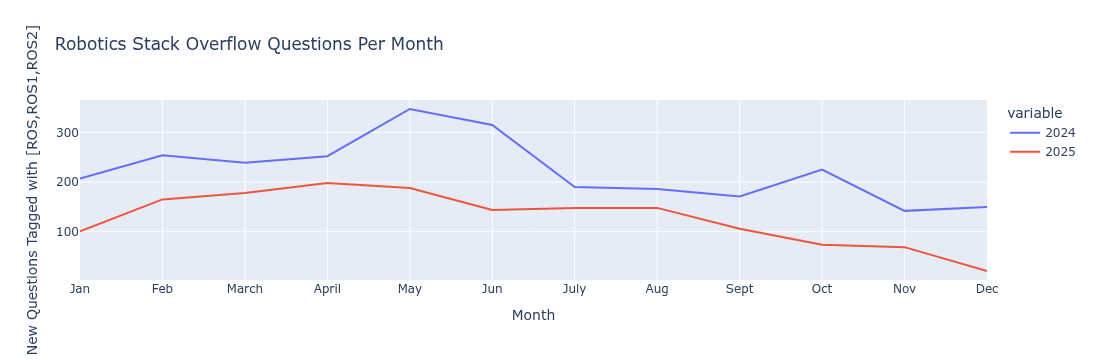

In [20]:
fig = px.line(new_df, x="month", y=["2024","2025"], title="Robotics Stack Overflow Questions Per Month")
fig.update_layout(
    xaxis_title="Month", 
    yaxis_title="New Questions Tagged with [ROS,ROS1,ROS2]",
    xaxis = dict(
        tickmode = 'array',
        tickvals = [i for i in range(1,13)],
        ticktext = ["Jan","Feb","March","April","May","Jun","July","Aug","Sept","Oct","Nov","Dec"]
    )
)

fig.show()

In [21]:
# we're ignoring the "ros1" tag and assuming the tag "ros" =="" ROS 1 
ros_q_this = len(ros_this) + len(ros2_this)
ros1_q_this = len(ros_this)
ros2_q_this = len(ros2_this)
ros_q_last = len(ros_last) + len(ros2_last)
ros1_q_last = len(ros_last)
ros2_q_last = len(ros2_last)
print("In {0} there were {1} ROS questions asked.".format(this_year,ros_q_this))
print("In {0} there were {1} ROS questions asked.".format(last_year,ros_q_last))
total_change = (ros_q_this-ros_q_last) / ros_q_last
print("In {0} there was a {1:+.2f}% change in ROS questions asked.".format(this_year,total_change*100.0))
this_prct_ros2 = ros2_q_this / ros_q_this
last_prct_ros2 = ros2_q_last / ros_q_last
print("In {0} {1:.2f}% of questions were ROS 2 and {2:.2f}% were ROS 1 ".format(this_year,this_prct_ros2*100.0,100.0-(this_prct_ros2*100.0)))
print("In {0} {1} questions were tagged \"ros2\" and {2} were tagged just \"ros\".".format(this_year,ros2_q_this,ros1_q_this))
print("----------------------------")
print("In {0} there were {1} ROS questions asked.".format(last_year,ros_q_last))
print("In {0} {1:.2f}% of questions were ROS 2 and {2:.2f}% were ROS 1 ".format(last_year,last_prct_ros2*100.0,100.0-(last_prct_ros2*100.0)))
print("In {0} {1} questions were tagged \"ros2\" and {2} were tagged just \"ros\".".format(last_year,ros2_q_last,ros1_q_last))


In 2025 there were 1540 ROS questions asked.
In 2024 there were 2678 ROS questions asked.
In 2025 there was a -42.49% change in ROS questions asked.
In 2025 94.09% of questions were ROS 2 and 5.91% were ROS 1 
In 2025 1449 questions were tagged "ros2" and 91 were tagged just "ros".
----------------------------
In 2024 there were 2678 ROS questions asked.
In 2024 92.64% of questions were ROS 2 and 7.36% were ROS 1 
In 2024 2481 questions were tagged "ros2" and 197 were tagged just "ros".


In [22]:
def summarize_tags(questions):
    summary = {}
    summary["tags"] = [] 
    summary["answers"] = 0
    summary["is_answered"] = 0
    summary["views"] = 0
    summary["scores"] = []
    summary["reputations"] = [] 
    for i in questions:
        summary["tags"] += i["tags"]
        summary["scores"].append(i["score"])
        summary["answers"] += i["answer_count"]
        if i["is_answered"]:
            summary["is_answered"] += 1
        summary["views"] += i["view_count"]
        if "reputation" in i["owner"]:
            summary["reputations"].append(i["owner"]["reputation"])
    summary["tags"] = Counter(summary["tags"])
    summary["total"] = len(questions)
    summary["prct_answered"] = summary["is_answered"] / len(questions)
    summary["total_answers"] = np.sum(summary["answers"])
    summary["total_views"] = np.sum(summary["views"])
    summary["median_reputation"] = np.median(summary["reputations"])
    return summary

In [23]:
# Summarize all of data into dictionary for ROS 1, ROS 2, and all ROS for this year and last
ros_this_summary = summarize_tags(ros_this)
ros2_this_summary = summarize_tags(ros2_this)
all_ros_this_summary = summarize_tags(ros_this+ros2_this)
ros_last_summary = summarize_tags(ros_last)
ros2_last_summary = summarize_tags(ros2_last)
all_ros_last_summary = summarize_tags(ros_last+ros2_last)
names = ["ros_this","ros_last","ros2_this","ros2_last","all_this","all_last"]
dsets = [ros_this_summary,ros_last_summary,ros2_this_summary,ros2_last_summary,all_ros_this_summary,all_ros_last_summary]

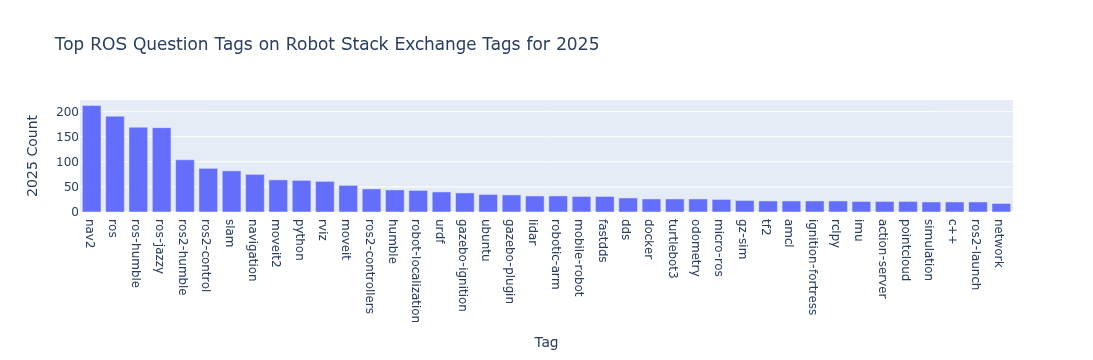

In [24]:
df = pd.DataFrame.from_dict(all_ros_this_summary["tags"], orient='index').reset_index()
df.columns.values[0] = "Tag"
temp = "{0} Count".format(this_year)
df.columns.values[1] = temp
df = df.sort_values(by=temp,ascending=False)
fig = px.bar(df[2:42], x="Tag", y=temp, title="Top ROS Question Tags on Robot Stack Exchange Tags for {0}".format(this_year))
fig.show()

In [25]:
# Fiddle with tags and create a data frame that shows tags by ROS1, ROS2, and all ROS last year
last_count = "{0} Count".format(last_year)
r1 = "ROS 1"
r2 = "ROS 2"
for i,row in df.iterrows():
    t = row["Tag"]
    df.at[i,last_count] = 0
    if t in all_ros_last_summary["tags"]:
        df.at[i,last_count]=int(all_ros_last_summary["tags"][t]) 
    df.at[i,r1] = 0
    if t in ros_this_summary["tags"]:
        df.at[i,r1]=int(ros_this_summary["tags"][t])  
    df.at[i,r2] = 0
    if t in ros2_this_summary["tags"]:
        df.at[i,r2]=int(ros2_this_summary["tags"][t])
df
df.to_csv("{0}TagCounts.csv".format(this_year))

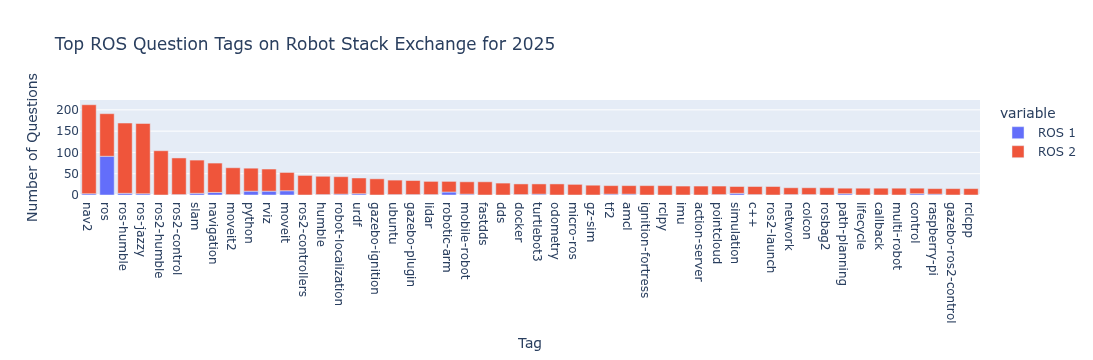

In [27]:
# The first two are ROS and ROS 2 so skip them
fig = px.bar(df[2:52], x="Tag", y=["ROS 1","ROS 2"],  title="Top ROS Question Tags on Robot Stack Exchange for {0}".format(this_year))
fig.update_layout(
        #autosize=False,
        #width=800,
        #height=400,
        #template='plotly_dark',
        yaxis_title=dict(text='Number of Questions'),#, font=dict(size=16, color='#FFFFFF')),
        #yaxis_title=dict(text='7 day avg', font=dict(size=16, color='#FFFFFF')),
        #plot_bgcolor='rgb(50, 50, 50)',
        #xaxis=dict(tickfont=dict(size=14, color='#FFFFFF')),
        #yaxis=dict(tickfont=dict(size=14, color='#FFFFFF')),
        #legend=dict(x=0.1, y=1.1, orientation='h', font=dict(color='#FFFFFF')),
        #margin=dict(l=10, r=10, t=100, b=50)
    )

fig.show()

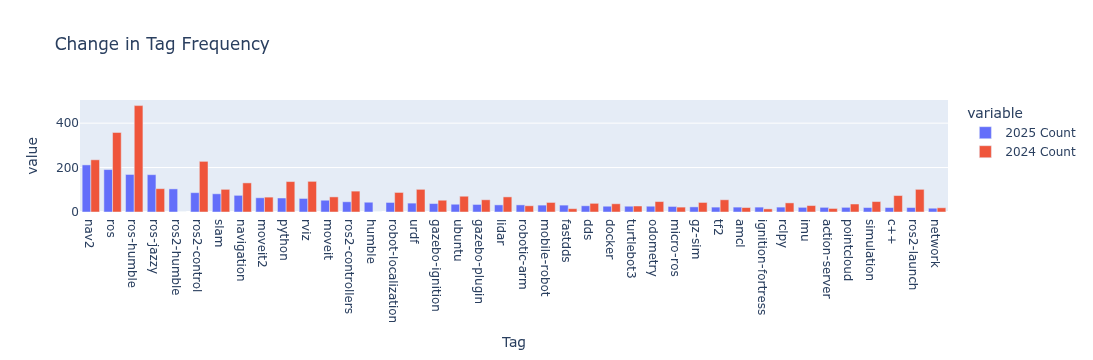

In [28]:
fig = px.bar(df[2:42], x="Tag", y=["2025 Count","2024 Count"], barmode='group',title="Change in Tag Frequency")
fig.show()

In [29]:
# Note that ROS2 is often in the set of ROS questions, so we probably should purge those questions so we don't get an overcount
print("In {0} the top ten ROS tags were: {1}\n".format(last_year,all_ros_last_summary["tags"].most_common()[2:11]))
print("In {0} the top ten ROS tags were: {1}\n".format(this_year,all_ros_this_summary["tags"].most_common()[2:11]))
print("In {0} the top ten ROS 1 tags were: {1}\n".format(this_year,ros_this_summary["tags"].most_common()[1:11]))
print("In {0} the top ten ROS 2 tags were: {1}\n".format(this_year,ros2_this_summary["tags"].most_common()[1:11]))


In 2024 the top ten ROS tags were: [('ros', 358), ('gazebo', 305), ('nav2', 235), ('ros2-control', 228), ('colcon', 148), ('rviz', 138), ('python', 137), ('navigation', 131), ('ros-jazzy', 105)]

In 2025 the top ten ROS tags were: [('nav2', 212), ('ros', 191), ('ros-humble', 169), ('ros-jazzy', 168), ('ros2-humble', 104), ('ros2-control', 87), ('slam', 82), ('navigation', 75), ('moveit2', 64)]

In 2025 the top ten ROS 1 tags were: [('gazebo', 14), ('ros-noetic', 12), ('moveit', 10), ('python', 9), ('rviz', 9), ('robotic-arm', 7), ('navigation', 6), ('ros-melodic', 6), ('simulation', 4), ('ros-humble', 4)]

In 2025 the top ten ROS 2 tags were: [('gazebo', 225), ('nav2', 209), ('ros-humble', 165), ('ros-jazzy', 165), ('ros2-humble', 104), ('ros', 100), ('ros2-control', 86), ('slam', 78), ('navigation', 69), ('moveit2', 63)]



In [30]:
# Percent answered 
print("In {0} there were {1} questions and {2} answers, {3:.2f}% of questions were answered.\n".format(last_year,all_ros_last_summary["total"],
                                                                                                       all_ros_last_summary["total_answers"],
                                                                                                       100.0*all_ros_last_summary["prct_answered"]
                                                                                                     ))
print("In {0} there were {1} questions and {2} answers, {3:.2f}% of questions were answered.\n".format(this_year,all_ros_this_summary["total"],
                                                                                                       all_ros_this_summary["total_answers"],
                                                                                                       100.0*all_ros_this_summary["prct_answered"]
                                                                                                     ))
print("-"*20)
print("In {0} there were {1} ROS 1 questions and {2} answers, {3:.2f}% of questions were answered.\n".format(last_year,ros_last_summary["total"],
                                                                                                       ros_last_summary["total_answers"],
                                                                                                       100.0*ros_last_summary["prct_answered"]
                                                                                                     ))
print("In {0} there were {1} ROS 1 questions and {2} answers, {3:.2f}% of questions were answered.\n".format(this_year,ros_this_summary["total"],
                                                                                                        ros_this_summary["total_answers"],
                                                                                                       100.0*ros_this_summary["prct_answered"]
                                                                                                     ))
print("-"*20)
print("In {0} there were {1} ROS 2 questions and {2} answers, {3:.2f}% of questions were answered.\n".format(last_year,ros2_last_summary["total"],
                                                                                                       ros2_last_summary["total_answers"],
                                                                                                       100.0*ros2_last_summary["prct_answered"]
                                                                                                     ))
print("In {0} there were {1} ROS 2 questions and {2} answers, {3:.2f}% of questions were answered.\n".format(this_year,ros2_this_summary["total"],
                                                                                                        ros2_this_summary["total_answers"],
                                                                                                       100.0*ros2_this_summary["prct_answered"]
                                                                                                     ))


In 2024 there were 2678 questions and 2703 answers, 65.65% of questions were answered.

In 2025 there were 1540 questions and 738 answers, 29.29% of questions were answered.

--------------------
In 2024 there were 197 ROS 1 questions and 179 answers, 52.28% of questions were answered.

In 2025 there were 91 ROS 1 questions and 32 answers, 13.19% of questions were answered.

--------------------
In 2024 there were 2481 ROS 2 questions and 2524 answers, 66.71% of questions were answered.

In 2025 there were 1449 ROS 2 questions and 706 answers, 30.30% of questions were answered.



In [31]:
# For a given tag, count the number of views for that tag, i.e. tell us the "most viewed tag"
def make_view_chart(q_list,tags):
    # Get views per tag, divided by the number of tagged questions
    counts = dict(tags)
    views = {}
    for c in counts.keys():
        views[c] = 0
    for q in q_list:
        for t in q["tags"]:
            views[t] += q["view_count"]
    normed = {}
    for k in counts.keys():
        normed[k] = views[k] / counts[k] 
    retval = []
    for k in counts.keys():
        retval.append({"tag":k,"views":views[k],"count":counts[k],"normed":normed[k]})
    return retval

output = make_view_chart(ros_this+ros2_this,all_ros_this_summary["tags"])

In [32]:
view_df = pd.DataFrame(data=output)
view_df = view_df.sort_values(by="normed",ascending=False)
view_df

,tag,views,count,normed
291,camera-depth-points,4746,3,1582.000000
177,mcap,3829,4,957.250000
335,controller-manager,2010,3,670.000000
373,ubuntu-noble,956,2,478.000000
2,rosinstall,3320,7,474.285714
...,...,...,...,...
267,ur3e,45,3,15.000000
284,raspbian,42,3,14.000000
340,publisher,39,3,13.000000
336,kuka,39,3,13.000000


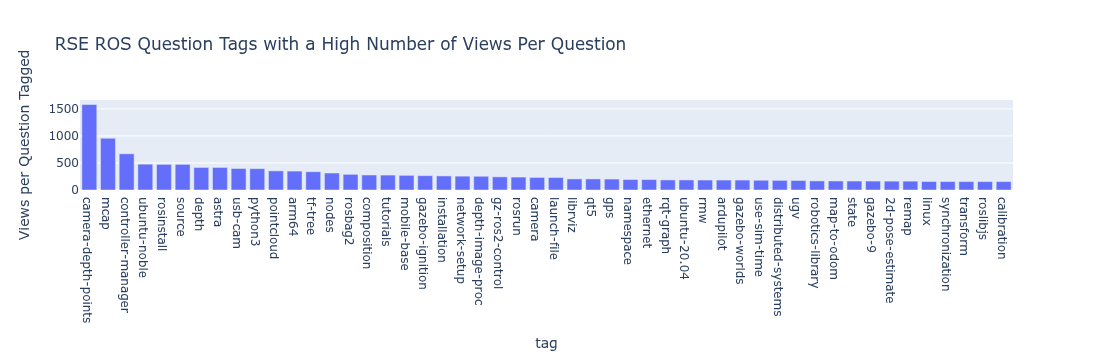

In [33]:
fig = px.bar(view_df[0:50], x="tag", y="normed", title="RSE ROS Question Tags with a High Number of Views Per Question")
fig.update_layout(
        #autosize=False,
        #width=800,
        #height=400,
        #template='plotly_dark',
        yaxis_title=dict(text='Views per Question Tagged'),#, font=dict(size=16, color='#FFFFFF')),
        #yaxis_title=dict(text='7 day avg', font=dict(size=16, color='#FFFFFF')),
        #plot_bgcolor='rgb(50, 50, 50)',
        #xaxis=dict(tickfont=dict(size=14, color='#FFFFFF')),
        #yaxis=dict(tickfont=dict(size=14, color='#FFFFFF')),
        #legend=dict(x=0.1, y=1.1, orientation='h', font=dict(color='#FFFFFF')),
        #margin=dict(l=10, r=10, t=100, b=50)
    )
fig.show()

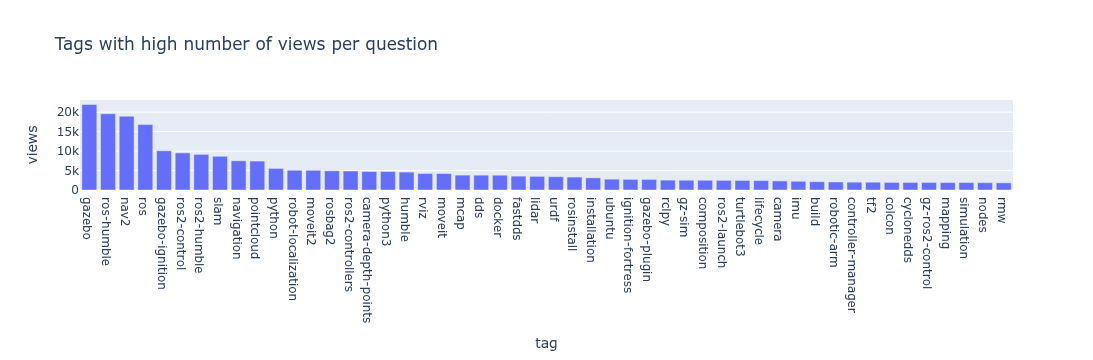

In [34]:
view_df = view_df.sort_values(by="views",ascending=False)
fig = px.bar(view_df[2:52], x="tag", y="views", title="Tags with high number of views per question")
fig.show()